<font size="+3">AF3 benchmark on TCR:epitope interactions</font> 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# AF3 input

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_6111/2485023933.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_pos_sub = (df_pos.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)))
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_6111/2485023933.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_neg_sub = (df_neg.groupby('E

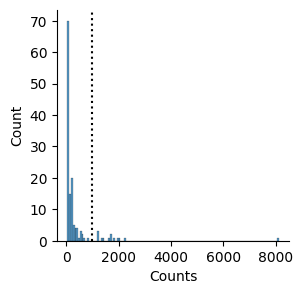

In [58]:
topdir = 'Supplementary_Tables'


df = pd.read_csv(f'{topdir}/Supplementary_Table_1.csv')

df_pos = df[(df['dataset_source'] == 'Public Paired Data') & (df['Label'] == 1)]
df_neg = df[(df['dataset_source'] == 'Public TCRs with undetermined specificities') & (df['Label'] == 0)]
df_neg.head()

counts = df_pos['Epitope'].value_counts().reset_index()
counts.columns = ['Epitope', 'Counts']

fig, ax = plt.subplots(1,1,figsize=(3,3))
sns.histplot(data=counts, x='Counts', ax=ax)
ax.axvline(1000, color='black', linestyle=':')
sns.despine()

# subsample positives n > 1000
df_pos_sub = (df_pos.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)))
df_pos_sub.to_csv('positives.csv', index=False)

# how many positives per epitope after subsampling
pos_counts = df_pos_sub['Epitope'].value_counts()

# sample matching number of negatives per epitope
df_neg_sub = (df_neg.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), pos_counts.get(x.name, 0)), random_state=42)).reset_index(drop=True))
df_neg_sub.to_csv('negatives.csv', index=False)



In [ ]:
df['peptide'] = 'RAKFKQLL'
df['species'] = 'HomoSapiens'
df['MHC'] = 'HLA_B0801'

In [ ]:
batches = ['positives', 'negatives']
exclude_mhc = ['DRB10101', 'DRB10701', 'DRB11501', 'na']

for batch in batches:
    os.makedirs(batch, exist_ok=True)
    df = pd.read_csv(f'{batch}.csv')
    df = df.drop(columns=['data_usage', 'Label', 'CV_id', 'dataset_source'])
    df['peptide'] = df['Epitope'].str.split('_').str[1]
    df['MHC'] = df['Epitope'].str.split('_').str[0]
    

    # exclude unclear mhcs
    df = df[~df['MHC'].isin(exclude_mhc)]

    # split alpha/beta if present
    mhc_split = df['MHC'].str.split('-', n=1, expand=True)

    # first allele always exists
    df['MHC_allele_a'] = 'HLA_' + mhc_split[0]

    # second allele only exists for entries with '-'
    df['MHC_allele_b'] = mhc_split[1]
    df['MHC_allele_b'] = 'HLA_' + df['MHC_allele_b'].fillna('NA')
    df.loc[mhc_split[1].isna(), 'MHC_allele_b'] = 'NA'
    df = df.drop(columns=['Epitope', 'MHC'])

    tcr_ids = np.array([f'tcr_{i+1:05d}' for i in range(len(df))])
    df.insert(0, 'id', tcr_ids)

    # for now only class I
    df = df[df['MHC_allele_b'] == 'NA']
    df = df.drop(columns=['MHC_allele_b'])
    print(np.unique(df['MHC_allele_a']))
    df.to_csv(f'{batch}/AF3_class_I.csv', index=False)

['HLA_A0101' 'HLA_A0201' 'HLA_A0301' 'HLA_A1101' 'HLA_A2402' 'HLA_A3002'
 'HLA_A6801' 'HLA_B0702' 'HLA_B0801' 'HLA_B1501' 'HLA_B3501' 'HLA_B3701'
 'HLA_B4001' 'HLA_B4402' 'HLA_B5101' 'HLA_B5701' 'HLA_E0103']
669
['HLA_A0101' 'HLA_A0201' 'HLA_A0301' 'HLA_A1101' 'HLA_A2402' 'HLA_A3002'
 'HLA_A6801' 'HLA_B0702' 'HLA_B0801' 'HLA_B1501' 'HLA_B3501' 'HLA_B3701'
 'HLA_B4001' 'HLA_B4402' 'HLA_B5101' 'HLA_B5701' 'HLA_E0103']


In [3]:
# new MHC alleles
df = pd.read_csv('positives/AF3_class_I.csv')
alleles = np.unique(df['MHC_allele_a'])
dico_alleles = {}
for i in alleles:
    dico_alleles[i.split('_')[1]] = i


df = pd.read_csv('/Users/roessner/Documents/PostDoc/Data/TCR_data/mhc_alleles/data_classI_MHC_I_sequences.txt', sep='\t')
df = df[df['Allele'].isin(dico_alleles)]
df['Allele'] = df['Allele'].map(dico_alleles)
df = df.rename(columns={'Sequence':'seq'})
df.to_csv('Alleles_tab.txt', sep='\t', index=False)
df

,Allele,seq
0,HLA_A0101,SHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQKMEP...
385,HLA_A0201,SHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEP...
1320,HLA_A0301,SHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEP...
1725,HLA_A1101,SHSMRYFYTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEP...
2232,HLA_A2402,SHSMRYFSTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEP...
3199,HLA_A3002,SHSMRYFSTSVSRPGSGEPRFIAVGYVDDTQFVRFDSDAASQRMEP...
4026,HLA_A6801,SHSMRYFYTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEP...
4342,HLA_B0702,SHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREEP...
4781,HLA_B0801,SHSMRYFDTAMSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREEP...
5328,HLA_B1501,SHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAP...
